In [5]:
import pandas as pd

df = pd.read_csv(r'C:\Users\Niyaz Ali\Documents\Retails_sales_capstone\Data\Raw_data\sales_data.csv')
print("missing values before cleaning")
print(df.isnull().sum())
print("\n")

df.columns = df.columns.str.strip()

# Replace missing store_id with a dummy value (string or number)
df['store_id'] = df['store_id'].fillna('ONLINE_ONLY')

# standardising formats
df['order_date']   = pd.to_datetime(df['order_date'], errors='coerce')
df['quantity']     = pd.to_numeric(df['quantity'], errors='coerce')
df['unit_price']   = pd.to_numeric(df['unit_price'], errors='coerce')
df['discount_pct'] = pd.to_numeric(df['discount_pct'], errors='coerce')
df['total_amount'] = pd.to_numeric(df['total_amount'], errors='coerce')

# removing duplicates
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())
print("\n")
df = df.drop_duplicates()
print("Rows after removing exact duplicates:", len(df))
print("\n")

# removing outliers
df = df.copy()
df = df[df['total_amount'] > 0]
df = df[df['quantity'] > 0]
df = df[df['unit_price'] > 0]
print("Rows after removing outliers", len(df))

# saving cleaned data
df.to_csv(r'C:\Users\Niyaz Ali\Documents\Retails_sales_capstone\Data\CLeaned_data\sales_cleaned.csv', index=False)
print("\nCleaned data saved to 'sales_cleaned.csv'")

missing values before cleaning
order_id           0
order_date         0
customer_id        0
product_id         0
store_id         992
sales_channel      0
quantity           0
unit_price         0
discount_pct       0
total_amount       0
dtype: int64


Total rows: 3060
Duplicate rows: 60


Rows after removing exact duplicates: 3000


Rows after removing outliers 3000

Cleaned data saved to 'sales_cleaned.csv'


In [2]:
import pandas as pd

customers = pd.read_csv(r'C:\Users\Niyaz Ali\Documents\Retails_sales_capstone\Data\Raw_data\customers.csv')
print("Missing values before cleaning:")
print(customers.isnull().sum())
print("\n")

# Clean column names
customers.columns = customers.columns.str.strip()
customers = customers.dropna(subset=['customer_id'])

# Handle missing values in other columns
customers['first_name'] = customers['first_name'].fillna('Unknown')
customers['last_name'] = customers['last_name'].fillna('Unknown')
customers['gender'] = customers['gender'].fillna('Not Specified')
customers['region'] = customers['region'].fillna('Unknown')
customers = customers.dropna(subset=['age', 'signup_date'])
customers = customers.dropna(subset=['signup_date', 'age'])


# Standardizing formats
customers['signup_date'] = pd.to_datetime(customers['signup_date'], errors='coerce')
customers['age'] = pd.to_numeric(customers['age'], errors='coerce')
customers['first_name'] = customers['first_name'].str.strip().str.title()
customers['last_name'] = customers['last_name'].str.strip().str.title()
customers['gender'] = customers['gender'].str.strip().str.title()
customers['region'] = customers['region'].str.strip().str.title()
gender_mapping = {
    'M': 'Male',
    'Male': 'Male',
    'F': 'Female',
    'Female': 'Female',
    'Other': 'Other',
    'Not Specified': 'Not Specified'
}
customers['gender'] = customers['gender'].map(gender_mapping).fillna('Not Specified')

# Removing duplicates
print("Total rows:", len(customers))
print("Duplicate rows:", customers.duplicated().sum())
print("\n")

customers = customers.drop_duplicates()
print("Rows after removing exact duplicates:", len(customers))
print("\n")

# Removing outliers
customers = customers.copy()
customers = customers[customers['age'] > 0]
customers = customers[customers['age'] <= 120]

print("Rows after removing outliers:", len(customers))

#adding a derived column age group
customers['age_group'] = pd.cut(customers['age'],
                                bins=[0, 18, 25, 35, 45, 55, 65, 120],
                                labels=['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

# Saving cleaned data
customers.to_csv(r'C:\Users\Niyaz Ali\Documents\Retails_sales_capstone\Data\CLeaned_data\customers_cleaned.csv', index=False)
print("\nCleaned data saved to 'customers_cleaned.csv'") 


Missing values before cleaning:
customer_id     0
first_name      0
last_name       0
gender          0
age            40
signup_date     0
region          0
dtype: int64


Total rows: 776
Duplicate rows: 16


Rows after removing exact duplicates: 760


Rows after removing outliers: 760

Cleaned data saved to 'customers_cleaned.csv'


In [3]:
import pandas as pd

# Cleaning the products file by removing missing values
products = pd.read_csv(r'C:\Users\Niyaz Ali\Documents\Retails_sales_capstone\Data\Raw_data\products.csv')

print("Missing values before cleaning:")
print(products.isnull().sum())
print("\n")

# Clean column names
products.columns = products.columns.str.strip()
products = products.dropna(subset=['product_id'])
products['product_name'] = products['product_name'].fillna('Unknown Product')
products['category'] = products['category'].fillna('Uncategorized')
products['brand'] = products['brand'].fillna('Unknown Brand')
products = products.dropna(subset=['cost_price', 'unit_price'])
products['margin_pct'] = products['margin_pct'].fillna(0)
products = products.dropna(subset=['cost_price', 'unit_price', 'margin_pct'])

# Standardizing formats
products['cost_price'] = pd.to_numeric(products['cost_price'], errors='coerce')
products['unit_price'] = pd.to_numeric(products['unit_price'], errors='coerce')
products['margin_pct'] = pd.to_numeric(products['margin_pct'], errors='coerce')
products['product_name'] = products['product_name'].str.strip().str.title()
products['category'] = products['category'].str.strip().str.title()
products['brand'] = products['brand'].str.strip().str.title()

# Removing duplicates
print("Total rows:", len(products))
print("Duplicate rows:", products.duplicated().sum())
print("\n")

products = products.drop_duplicates()
print("Rows after removing exact duplicates:", len(products))
print("\n")

# Removing outliers
products = products.copy()
products = products[products['cost_price'] > 0]
products = products[products['unit_price'] > 0]
products = products[products['unit_price'] >= products['cost_price']]  # Unit price should be >= cost
products = products[products['margin_pct'] >= 0]
products = products[products['margin_pct'] <= 100]

print("Rows after removing outliers:", len(products))

#creating a derived column "price category"
products['price_category'] = pd.cut(products['unit_price'],
                                    bins=[0, 20, 50, 100, 500, 10000],
                                    labels=['Budget', 'Economy', 'Mid-Range', 'Premium', 'Luxury'])

# Saving cleaned data
products.to_csv(r'C:\Users\Niyaz Ali\Documents\Retails_sales_capstone\Data\CLeaned_data\products_cleaned.csv', index=False)
print("\nCleaned data saved to 'products_cleaned.csv'")

Missing values before cleaning:
product_id       0
product_name     0
category         0
brand           60
cost_price       0
unit_price       0
margin_pct       0
dtype: int64


Total rows: 1224
Duplicate rows: 24


Rows after removing exact duplicates: 1200


Rows after removing outliers: 1200

Cleaned data saved to 'products_cleaned.csv'


In [5]:
import pandas as pd

# Cleaning the returns file by removing missing values
returns = pd.read_csv(r'C:\Users\Niyaz Ali\Documents\Retails_sales_capstone\Data\Raw_data\returns.csv')

print("Missing values before cleaning:")
print(returns.isnull().sum())
print("\n")

# Clean column names
returns.columns = returns.columns.str.strip()
returns = returns.dropna(subset=['return_id', 'order_id'])
returns['return_reason'] = returns['return_reason'].fillna('Not Specified')
returns = returns.dropna(subset=['return_date'])

# Drop rows where date conversion failed
returns = returns.dropna(subset=['return_date'])

# Standardizing formats
returns['return_date'] = pd.to_datetime(returns['return_date'], errors='coerce')
returns['return_reason'] = returns['return_reason'].str.strip().str.title()

# Standardize return reasons (group similar reasons)
reason_mapping = {
    'Defective': 'Defective',
    'Damaged': 'Defective',
    'Faulty': 'Defective',
    'Late Delivery': 'Late Delivery',
    'Delayed': 'Late Delivery',
    'Wrong Item': 'Wrong Item',
    'Incorrect Item': 'Wrong Item',
    'Changed Mind': 'Changed Mind',
    'Not As Described': 'Not As Described',
    'Not Specified': 'Not Specified'
}
returns['return_reason'] = returns['return_reason'].replace(reason_mapping)

# Removing duplicates
print("Total rows:", len(returns))
print("Duplicate rows:", returns.duplicated().sum())
print("\n")

returns = returns.drop_duplicates()
print("Rows after removing exact duplicates:", len(returns))
print("\n")

# Check for duplicate return_ids
duplicate_return_ids = returns.duplicated(subset=['return_id']).sum()
print("Duplicate return_ids:", duplicate_return_ids)

returns = returns.drop_duplicates(subset=['return_id'], keep='first')
print("Rows after removing duplicate return_ids:", len(returns))
print("\n")

# Removing outliers (if you have additional numeric columns)
returns = returns.copy()

# If you have return_date, check for future dates
returns = returns[returns['return_date'] <= pd.Timestamp.now()]

print("Rows after removing outliers:", len(returns))

#adding year,month and quarter columns
returns['return_year'] = returns['return_date'].dt.year
returns['return_month'] = returns['return_date'].dt.month
returns['return_month_name'] = returns['return_date'].dt.month_name()
returns['return_quarter'] = returns['return_date'].dt.quarter

# Saving cleaned data
returns.to_csv(r'C:\Users\Niyaz Ali\Documents\Retails_sales_capstone\Data\CLeaned_data\returns_cleaned.csv', index=False)
print("\nCleaned data saved to 'returns_cleaned.csv'")


Missing values before cleaning:
return_id        0
order_id         0
return_date      0
return_reason    0
dtype: int64


Total rows: 204
Duplicate rows: 4


Rows after removing exact duplicates: 200


Duplicate return_ids: 0
Rows after removing duplicate return_ids: 200


Rows after removing outliers: 200

Cleaned data saved to 'returns_cleaned.csv'


In [6]:
import pandas as pd

# Cleaning the stores file by removing missing values
stores = pd.read_csv(r'C:\Users\Niyaz Ali\Documents\Retails_sales_capstone\Data\Raw_data\stores.csv')

print("Missing values before cleaning:")
print(stores.isnull().sum())
print("\n")

# Clean column names
stores.columns = stores.columns.str.strip()
stores = stores.dropna(subset=['store_id'])
stores['store_name'] = stores['store_name'].fillna('Unknown Store')
stores['store_type'] = stores['store_type'].fillna('Not Specified')
stores['region'] = stores['region'].fillna('Unknown Region')
stores['city'] = stores['city'].fillna('Unknown City')

# Drop rows where conversion failed
stores = stores.dropna(subset=['operating_cost'])

# Handle missing operating_cost
stores['operating_cost'] = stores['operating_cost'].fillna(stores['operating_cost'].median())

# Standardizing formats
stores['operating_cost'] = pd.to_numeric(stores['operating_cost'], errors='coerce')
stores['store_name'] = stores['store_name'].str.strip().str.title()
stores['store_type'] = stores['store_type'].str.strip().str.title()
stores['region'] = stores['region'].str.strip().str.title()
stores['city'] = stores['city'].str.strip().str.title()
store_type_mapping = {
    'Mall': 'Mall',
    'Shopping Mall': 'Mall',
    'Standalone': 'Standalone',
    'Stand-Alone': 'Standalone',
    'Outlet': 'Outlet',
    'Pop-Up': 'Pop-Up',
    'Not Specified': 'Not Specified'
}
stores['store_type'] = stores['store_type'].replace(store_type_mapping)

# Removing duplicates
print("Total rows:", len(stores))
print("Duplicate rows:", stores.duplicated().sum())
print("\n")

stores = stores.drop_duplicates()
print("Rows after removing exact duplicates:", len(stores))
print("\n")

# Check for duplicate store_ids
duplicate_store_ids = stores.duplicated(subset=['store_id']).sum()
print("Duplicate store_ids:", duplicate_store_ids)

stores = stores.drop_duplicates(subset=['store_id'], keep='first')
print("Rows after removing duplicate store_ids:", len(stores))
print("\n")

# Removing outliers
stores = stores.copy()
stores = stores[stores['operating_cost'] > 0]
stores = stores[stores['operating_cost'] <= 1000000] 

print("Rows after removing outliers:", len(stores))

#creating derived column "cost category"
stores['cost_category'] = pd.cut(stores['operating_cost'],
                                 bins=[0, 50000, 100000, 200000, 500000, 10000000],
                                 labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# Saving cleaned data
stores.to_csv(r'C:\Users\Niyaz Ali\Documents\Retails_sales_capstone\Data\CLeaned_data\stores_cleaned.csv', index=False)
print("\nCleaned data saved to 'stores_cleaned.csv'")

Missing values before cleaning:
store_id          0
store_name        0
store_type        0
region            0
city              0
operating_cost    0
dtype: int64


Total rows: 61
Duplicate rows: 1


Rows after removing exact duplicates: 60


Duplicate store_ids: 0
Rows after removing duplicate store_ids: 60


Rows after removing outliers: 60

Cleaned data saved to 'stores_cleaned.csv'


In [5]:
# performing basic eda

import pandas as pd
import matplotlib.pyplot as plt

# Read cleaned data with full paths
sales = pd.read_csv(r'C:\Users\Niyaz Ali\Documents\Retails_sales_capstone\Data\CLeaned_data\sales_cleaned.csv')
customers = pd.read_csv(r'C:\Users\Niyaz Ali\Documents\Retails_sales_capstone\Data\CLeaned_data\customers_cleaned.csv')
products = pd.read_csv(r'C:\Users\Niyaz Ali\Documents\Retails_sales_capstone\Data\CLeaned_data\products_cleaned.csv')
returns = pd.read_csv(r'C:\Users\Niyaz Ali\Documents\Retails_sales_capstone\Data\CLeaned_data\returns_cleaned.csv')
stores = pd.read_csv(r'C:\Users\Niyaz Ali\Documents\Retails_sales_capstone\Data\CLeaned_data\stores_cleaned.csv')

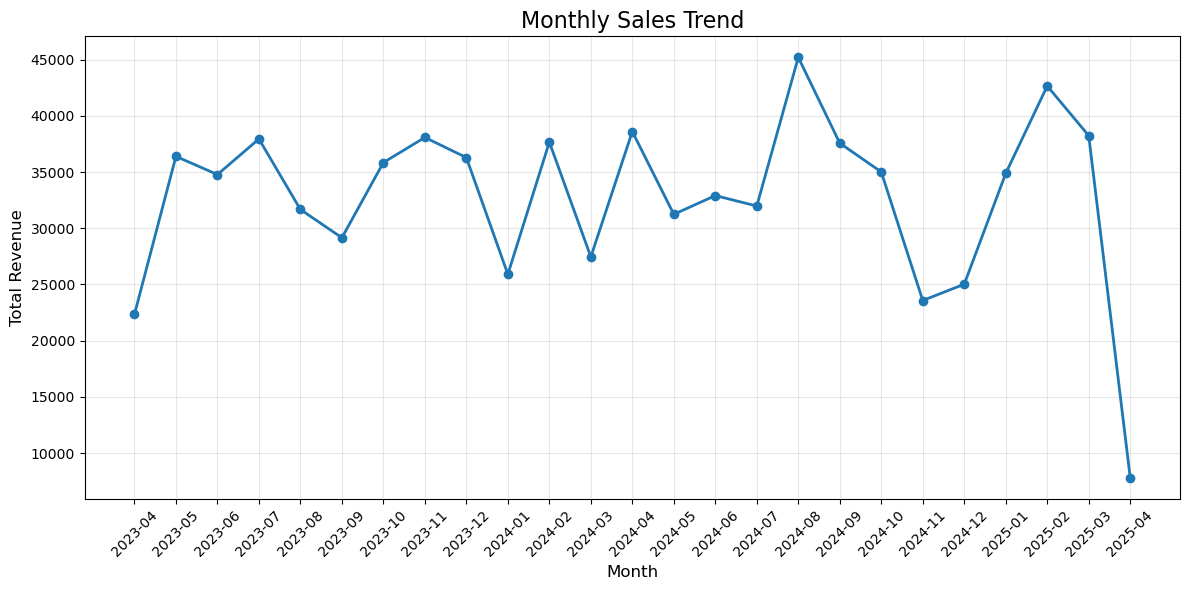


Sales by Channel:
sales_channel
In-Store    578621.54
Online      239559.03
Name: total_amount, dtype: float64


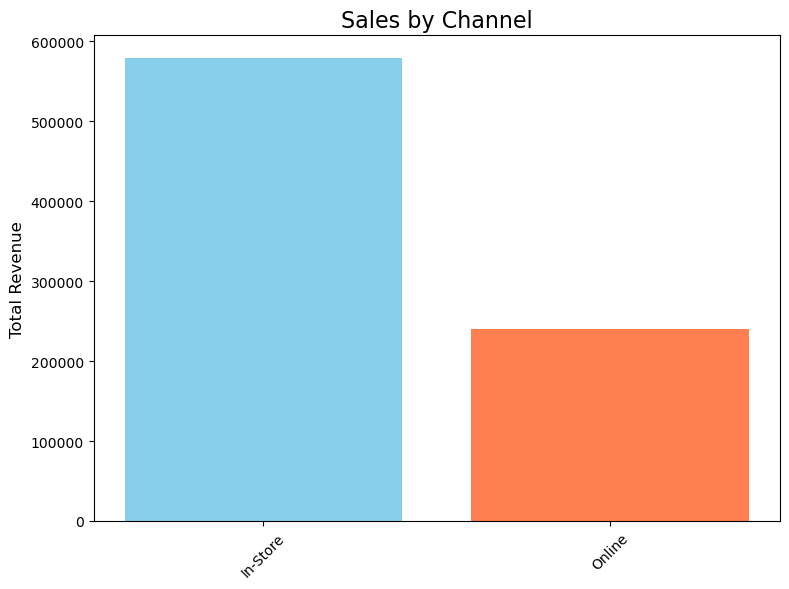

In [6]:
# sales trend analysis
sales['order_date'] = pd.to_datetime(sales['order_date'])

# Monthly sales trend
monthly_sales = sales.groupby(sales['order_date'].dt.to_period('M'))['total_amount'].sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Sales by channel
channel_sales = sales.groupby('sales_channel')['total_amount'].sum()
print("\nSales by Channel:")
print(channel_sales)

plt.figure(figsize=(8, 6))
plt.bar(channel_sales.index, channel_sales.values, color=['skyblue', 'coral'])
plt.title('Sales by Channel', fontsize=16)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Top 10 Customers by Revenue:
customer_id
C0399    9675.38
C0209    9546.48
C0386    8290.62
C0478    7786.44
C0203    7138.87
C0390    6549.75
C0630    6485.74
C0155    4679.56
C0633    4525.03
C0359    4434.69
Name: total_amount, dtype: float64


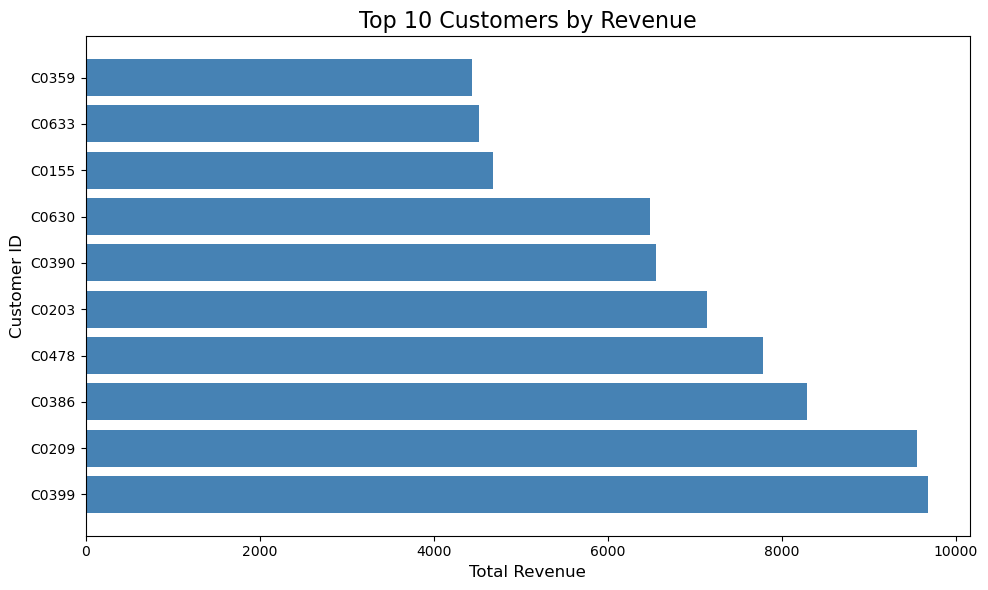

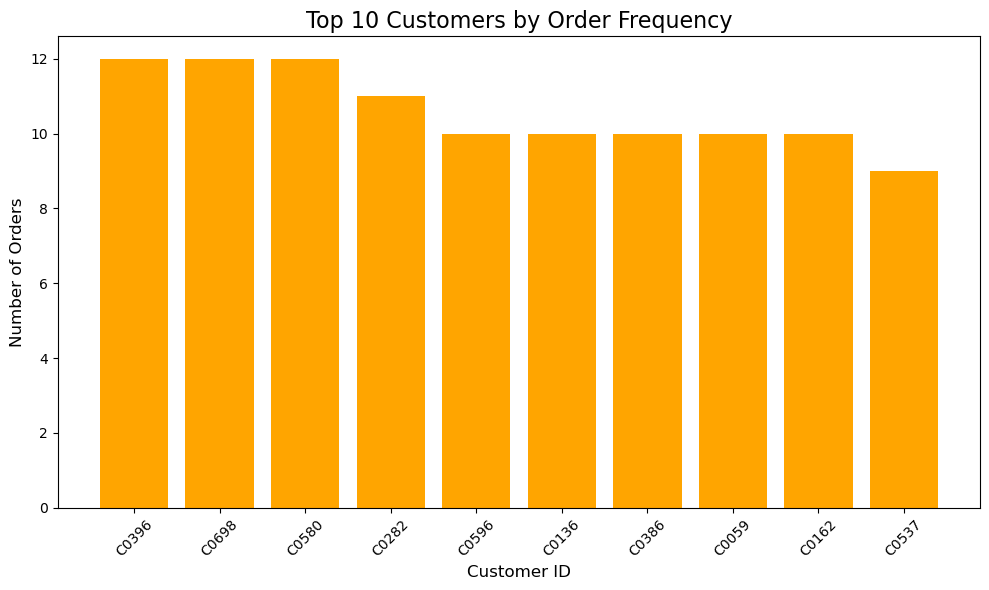

In [7]:
# customer analysis

# Top 10 customers by revenue
top_customers = sales.groupby('customer_id')['total_amount'].sum().sort_values(ascending=False).head(10)

print("\nTop 10 Customers by Revenue:")
print(top_customers)

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_customers)), top_customers.values, color='steelblue')
plt.yticks(range(len(top_customers)), top_customers.index)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Customer ID', fontsize=12)
plt.title('Top 10 Customers by Revenue', fontsize=16)
plt.tight_layout()
plt.show()

# Customer purchase frequency
customer_orders = sales.groupby('customer_id')['order_id'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(range(len(customer_orders)), customer_orders.values, color='orange')
plt.xticks(range(len(customer_orders)), customer_orders.index, rotation=45)
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.title('Top 10 Customers by Order Frequency', fontsize=16)
plt.tight_layout()
plt.show()


Top 10 Products by Quantity:
product_name
Brandc House        40
Branda Feel         33
Brandc Decision     33
Brandb Stop         32
Brandc Apply        27
Brandb Choice       27
Brandb Few          26
Brandc Along        25
Branda Necessary    24
Brandc Occur        24
Name: quantity, dtype: int64


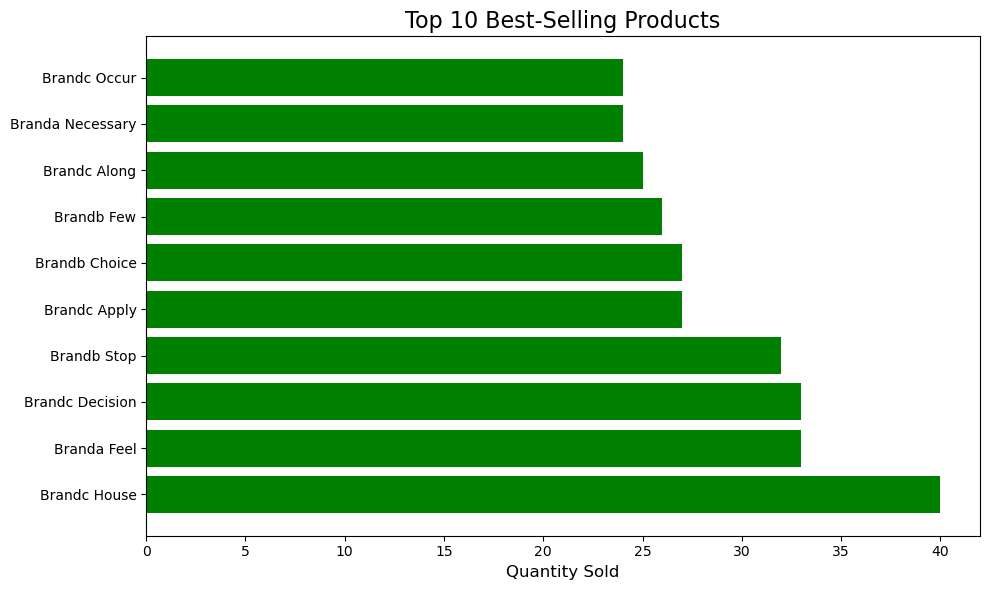

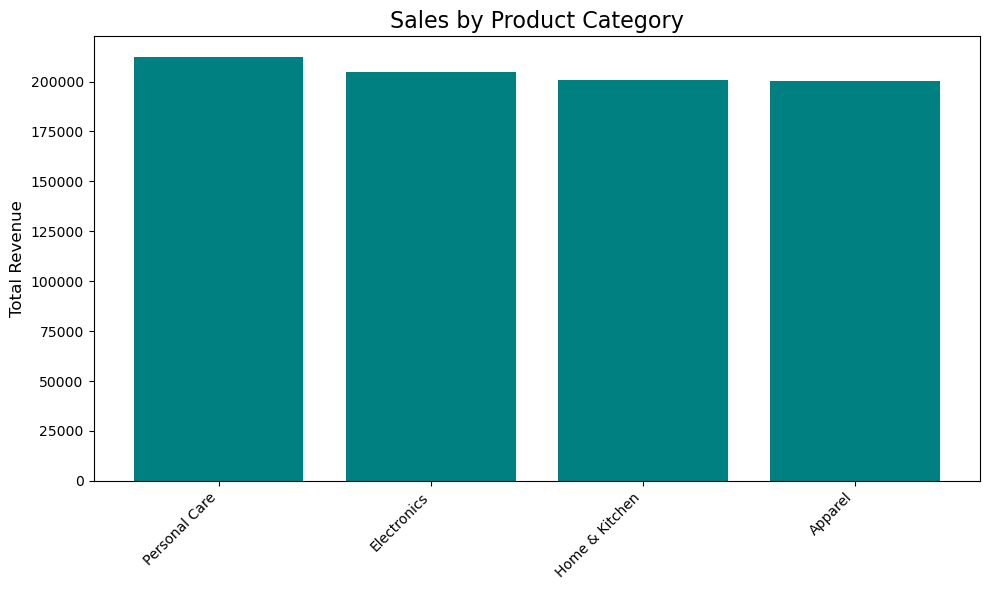

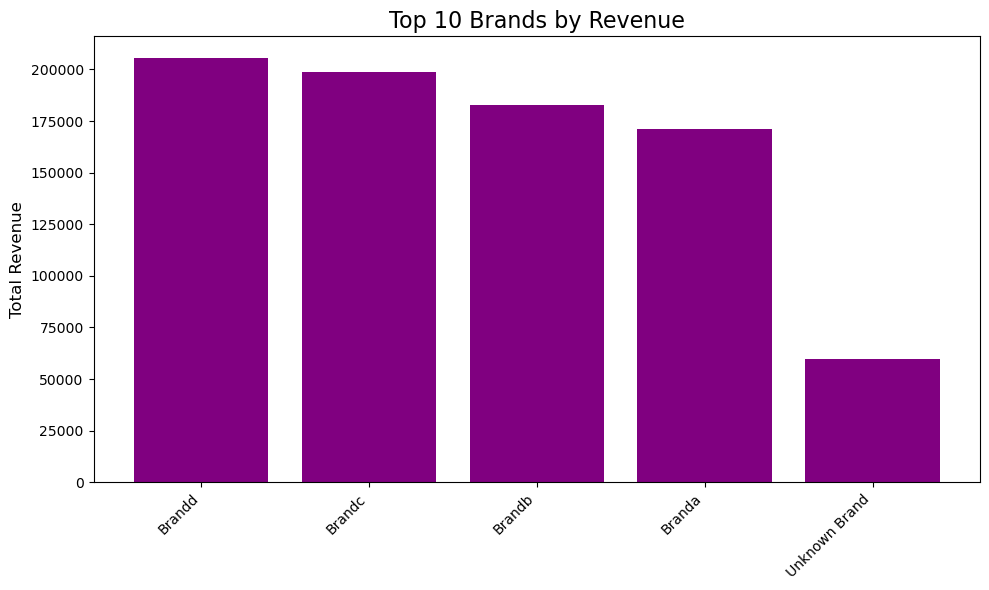

In [8]:
# product analysis

sales_products = sales.merge(products, on='product_id')

# Top selling products by quantity
top_products = sales_products.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10)

print("\nTop 10 Products by Quantity:")
print(top_products)

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_products)), top_products.values, color='green')
plt.yticks(range(len(top_products)), top_products.index)
plt.xlabel('Quantity Sold', fontsize=12)
plt.title('Top 10 Best-Selling Products', fontsize=16)
plt.tight_layout()
plt.show()

# Sales by category
category_sales = sales_products.groupby('category')['total_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(range(len(category_sales)), category_sales.values, color='teal')
plt.xticks(range(len(category_sales)), category_sales.index, rotation=45, ha='right')
plt.ylabel('Total Revenue', fontsize=12)
plt.title('Sales by Product Category', fontsize=16)
plt.tight_layout()
plt.show()

# Revenue by brand (top 10)
brand_revenue = sales_products.groupby('brand')['total_amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(range(len(brand_revenue)), brand_revenue.values, color='purple')
plt.xticks(range(len(brand_revenue)), brand_revenue.index, rotation=45, ha='right')
plt.ylabel('Total Revenue', fontsize=12)
plt.title('Top 10 Brands by Revenue', fontsize=16)
plt.tight_layout()
plt.show()

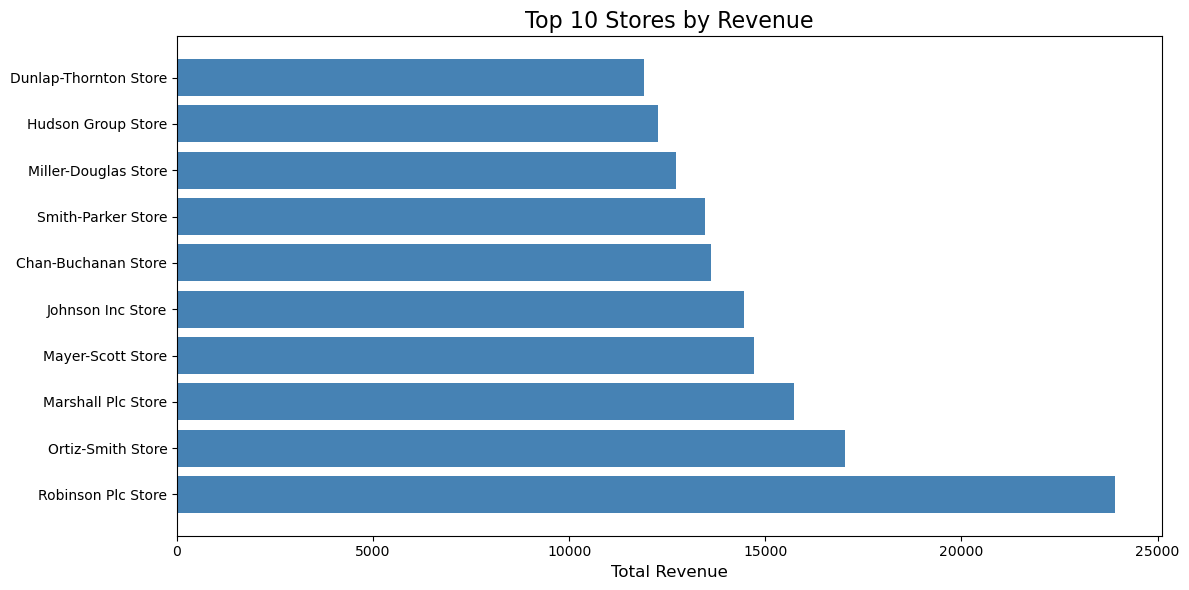

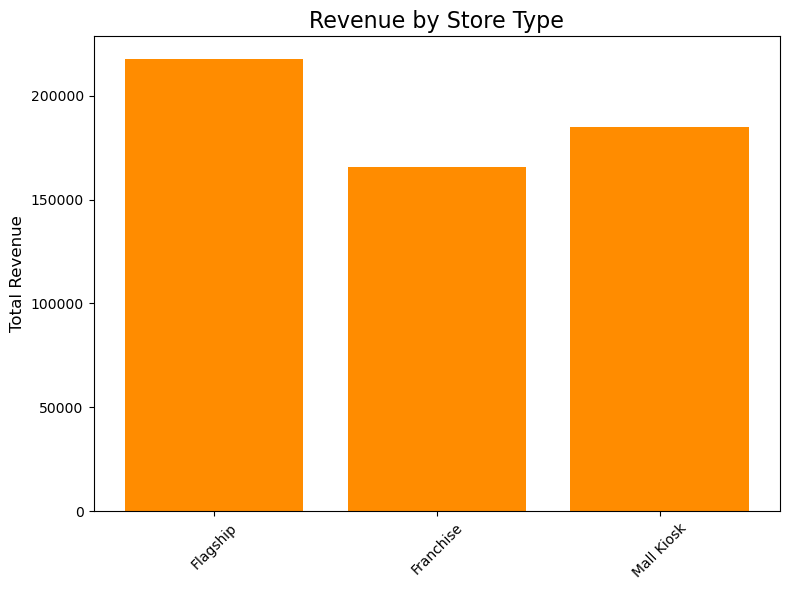

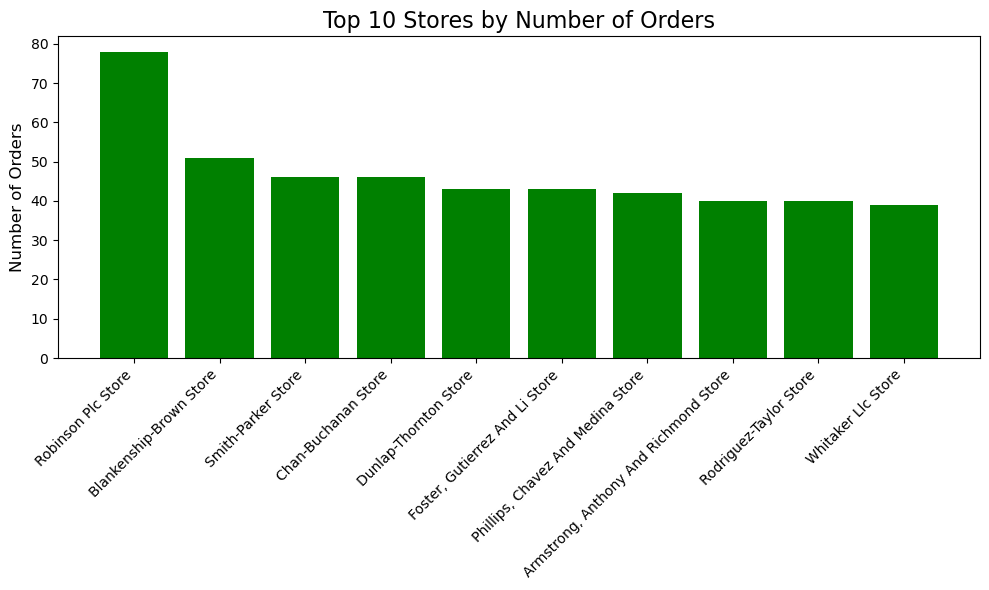

In [9]:
# store analysis 
sales_stores = sales.merge(stores, on='store_id')

# Revenue by store (top 10)
store_revenue = sales_stores.groupby('store_name')['total_amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(range(len(store_revenue)), store_revenue.values, color='steelblue')
plt.yticks(range(len(store_revenue)), store_revenue.index)
plt.xlabel('Total Revenue', fontsize=12)
plt.title('Top 10 Stores by Revenue', fontsize=16)
plt.tight_layout()
plt.show()

# Revenue by store type
store_type_revenue = sales_stores.groupby('store_type')['total_amount'].sum()

plt.figure(figsize=(8, 6))
plt.bar(range(len(store_type_revenue)), store_type_revenue.values, color='darkorange')
plt.xticks(range(len(store_type_revenue)), store_type_revenue.index, rotation=45)
plt.ylabel('Total Revenue', fontsize=12)
plt.title('Revenue by Store Type', fontsize=16)
plt.tight_layout()
plt.show()

# Orders by store (top 10)
store_orders = sales_stores.groupby('store_name')['order_id'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(range(len(store_orders)), store_orders.values, color='green')
plt.xticks(range(len(store_orders)), store_orders.index, rotation=45, ha='right')
plt.ylabel('Number of Orders', fontsize=12)
plt.title('Top 10 Stores by Number of Orders', fontsize=16)
plt.tight_layout()
plt.show()


Return Rate: 6.67%
Total Orders: 3,000
Total Returns: 200


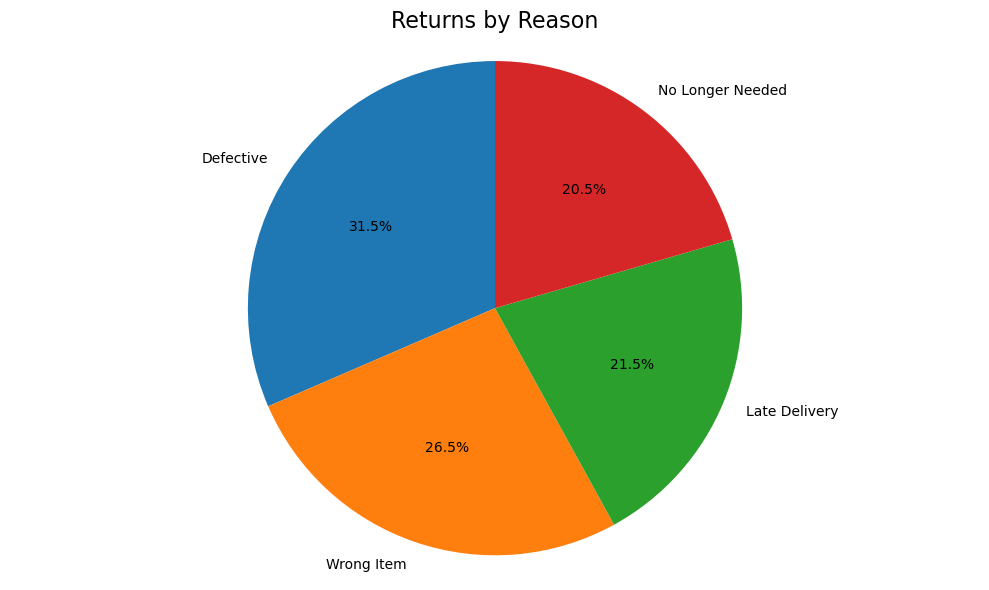

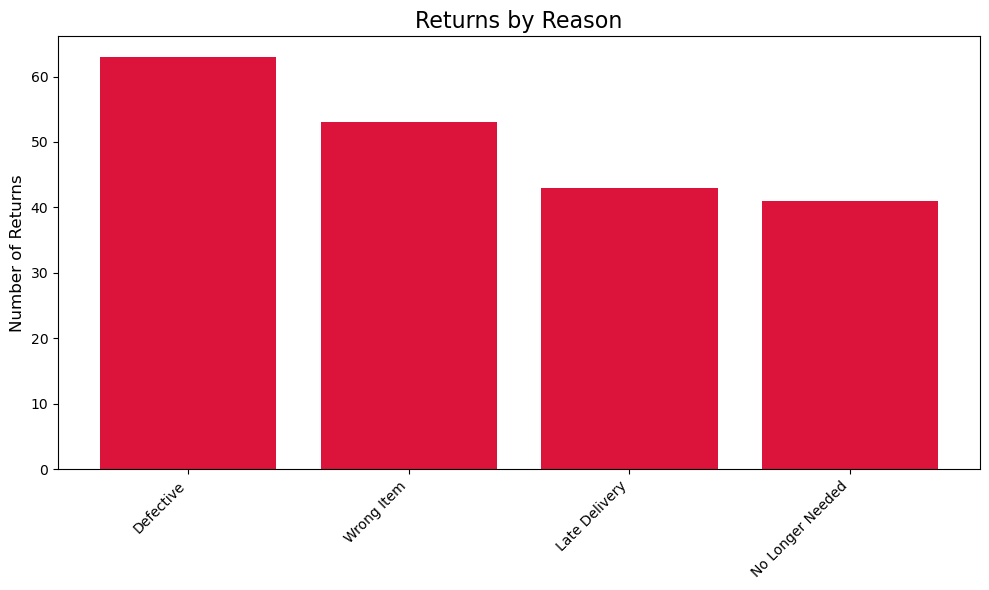

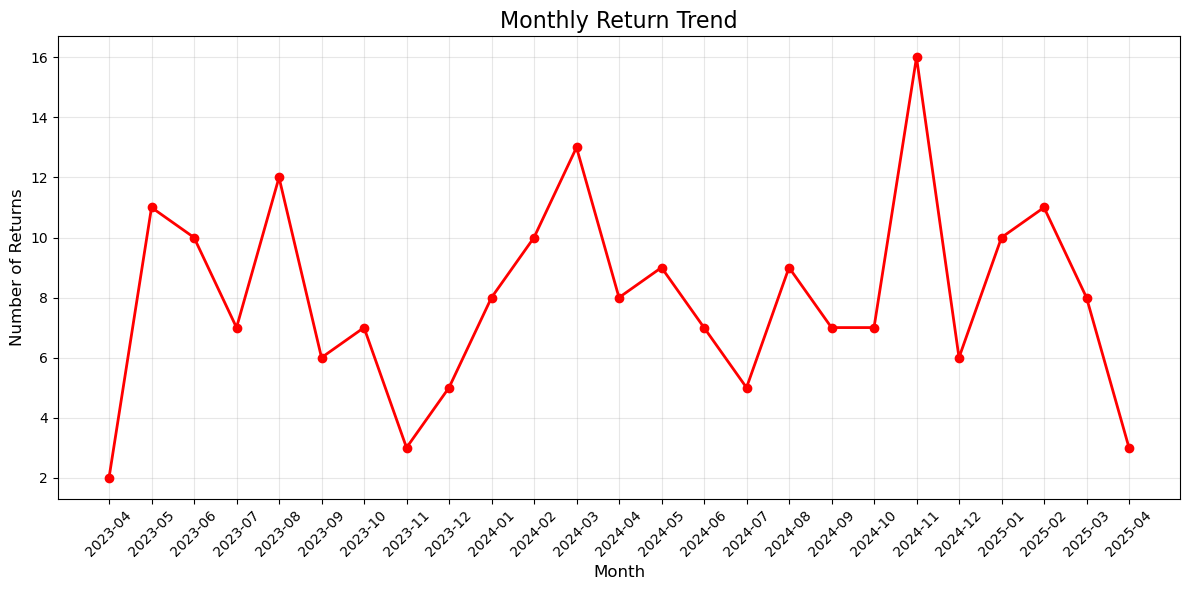

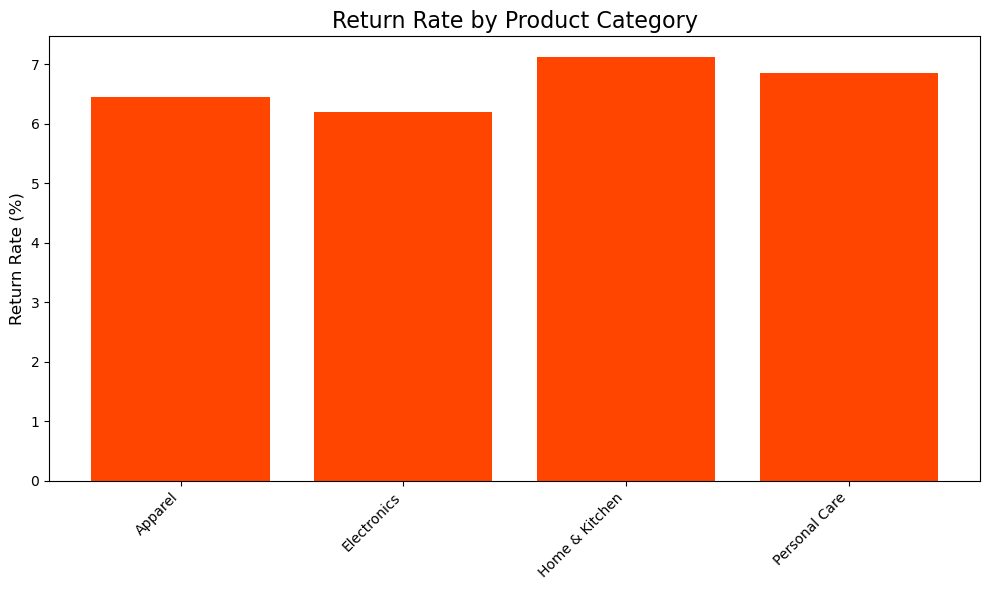

In [13]:
# return analysis 

# Return rate
total_orders = len(sales)
total_returns = len(returns)
return_rate = (total_returns / total_orders) * 100

print(f"\nReturn Rate: {return_rate:.2f}%")
print(f"Total Orders: {total_orders:,}")
print(f"Total Returns: {total_returns:,}")

# Returns by reason
return_reasons = returns['return_reason'].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(return_reasons.values, labels=return_reasons.index, autopct='%1.1f%%', startangle=90)
plt.title('Returns by Reason', fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Bar chart version
plt.figure(figsize=(10, 6))
plt.bar(range(len(return_reasons)), return_reasons.values, color='crimson')
plt.xticks(range(len(return_reasons)), return_reasons.index, rotation=45, ha='right')
plt.ylabel('Number of Returns', fontsize=12)
plt.title('Returns by Reason', fontsize=16)
plt.tight_layout()
plt.show()

# Monthly return trend
returns['return_date'] = pd.to_datetime(returns['return_date'])
monthly_returns = returns.groupby(returns['return_date'].dt.to_period('M')).size()

plt.figure(figsize=(12, 6))
plt.plot(monthly_returns.index.astype(str), monthly_returns.values, marker='o', color='red', linewidth=2)
plt.title('Monthly Return Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Returns', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Return rate by category
sales_products_returns = sales_products.merge(returns[['order_id', 'return_id']], on='order_id', how='left')
category_returns = sales_products_returns.groupby('category').agg({
    'order_id': 'count',
    'return_id': 'count'
}).rename(columns={'order_id': 'total_orders', 'return_id': 'returns'})
category_returns['return_rate'] = (category_returns['returns'] / category_returns['total_orders'] * 100).fillna(0)

plt.figure(figsize=(10, 6))
plt.bar(range(len(category_returns)), category_returns['return_rate'].values, color='orangered')
plt.xticks(range(len(category_returns)), category_returns.index, rotation=45, ha='right')
plt.ylabel('Return Rate (%)', fontsize=12)
plt.title('Return Rate by Product Category', fontsize=16)
plt.tight_layout()
plt.show()